In [3]:
import glob
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math as mt
import statistics as st
import scipy as sp
from draw_graph import Scatter, Stripplot
from PIL import Image
import seaborn as sns
from calibration import lifetime_to_temperature, temperature_to_intensity_ratio

In [4]:
#パスの読み込み
file_path = glob.glob('./100mW_deltaT/*.csv')
file_path.sort()

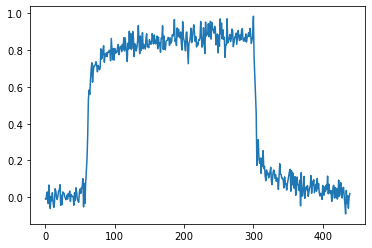

In [5]:
average_100mW = 0
deltaT_100mW = []

for path in file_path:
    decay = np.array(pd.read_csv(path, encoding='utf-16le', sep=',')['Channel.001'][1:], dtype = 'float32')
    diff = decay[:-5] - decay[5:]
    time = np.argmin(diff)
    extract = decay[time-300 : time+140]
    coefficient = (np.mean(extract[-30:]) - np.mean(extract[:30]))/440
    extract = extract - coefficient*range(len(extract))
    extract = extract/extract[0]
    extract = -np.log(extract/np.mean(extract[:5]))/0.0351
    average_100mW += extract
    deltaT_100mW.append(extract[300])
average_100mW = average_100mW/10
plt.plot(average_100mW)
plt.show()

In [6]:
#パスの読み込み
file_path = glob.glob('./130mW_deltaT/*.csv')
file_path.sort()

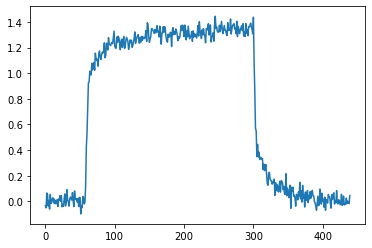

In [7]:
average_130mW = 0
deltaT_130mW = []

for path in file_path:
    decay = np.array(pd.read_csv(path, encoding='utf-16le', sep=',')['Channel.001'][1:], dtype = 'float32')
    diff = decay[:-5] - decay[5:]
    time = np.argmin(diff)
    extract = decay[time-300 : time+140]
    coefficient = (np.mean(extract[-30:]) - np.mean(extract[:30]))/440
    extract = extract - coefficient*range(len(extract))
    extract = extract/extract[0]
    extract = -np.log(extract/np.mean(extract[:5]))/0.0351
    average_130mW += extract
    deltaT_130mW.append(extract[300])
average_130mW = average_130mW/10
plt.plot(average_130mW)
plt.show()

In [8]:
#パスの読み込み
file_path = glob.glob('./160mW_deltaT/*.csv')
file_path.sort()

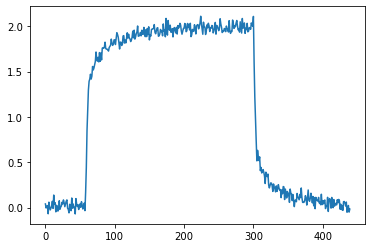

In [9]:
average_160mW = 0
deltaT_160mW = []

for path in file_path:
    decay = np.array(pd.read_csv(path, encoding='utf-16le', sep=',')['Channel.001'][1:], dtype = 'float32')
    diff = decay[:-5] - decay[5:]
    time = np.argmin(diff)
    extract = decay[time-300 : time+140]
    coefficient = (np.mean(extract[-30:]) - np.mean(extract[:30]))/440
    extract = extract - coefficient*range(len(extract))
    extract = extract/extract[0]
    extract = -np.log(extract/np.mean(extract[:5]))/0.0351
    average_160mW += extract
    deltaT_160mW.append(extract[300])
average_160mW = average_160mW/10
plt.plot(average_160mW)
plt.show()

In [10]:
print(np.mean(deltaT_100mW))
print(np.mean(deltaT_130mW))
print(np.mean(deltaT_160mW))

0.9848361575387736
1.4365628515716151
2.107877703044711


In [11]:
print(st.stdev(deltaT_100mW))
print(st.stdev(deltaT_130mW))
print(st.stdev(deltaT_160mW))

0.20417615086428442
0.21690762170677294
0.24038011752245694


In [12]:
print(st.stdev(deltaT_100mW)/np.sqrt(len(deltaT_100mW)))
print(st.stdev(deltaT_130mW)/np.sqrt(len(deltaT_130mW)))
print(st.stdev(deltaT_160mW)/np.sqrt(len(deltaT_160mW)))

0.06456616806172953
0.06859221264435819
0.07601486755899152
